# 오토 인코더 설계

In [39]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils import data
from torchvision import datasets,transforms, utils
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.datasets import FashionMNIST

USE_MPS = torch.backends.mps.is_available()
DEVICE=torch.device('mps' if USE_MPS else 'cpu')

In [2]:
tr_ds=datasets.MNIST(root='./data/',
                     train=True,
                     download=True,
                     transform=transforms.Compose([transforms.ToTensor()]))

In [3]:
BATCH_SIZE=60000
tr_ds_loader=torch.utils.data.DataLoader(
    dataset=tr_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)
img,_=next(iter(tr_ds_loader))
img.shape
img.mean(),img.std()

(tensor(0.1307), tensor(0.3081))

In [4]:
BATCH_SIZE=64
EPOCHS=10

In [56]:
# 데이터 수정 (노이즈 삽입)
# 1. 데이터 준비
transform=transforms.Compose([
    #transforms.RandomHorizontalFlip(),#데이터 증강(노이즈삽입)
    transforms.ToTensor(),#입력 데이터 정리
    #transforms.Normalize((0.1307,),(0.3081,))
])#데이터 사용 방식 내용 결정
tr_ds_loader=torch.utils.data.DataLoader(
    datasets.MNIST('./data/',
        train=True,
        download=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
tt_ds_loader=torch.utils.data.DataLoader(
    datasets.MNIST('./data/',
        train=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [6]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder=nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,12),
            nn.ReLU(),
            nn.Linear(12,3)
            )
        self.decoder=nn.Sequential(
            nn.Linear(3,12),
            nn.ReLU(),
            nn.Linear(12,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,28*28),
            nn.Sigmoid()
            )
    def forward(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return encoded,decoded

In [7]:
autoencoder=Model().to(DEVICE)
opt=optim.Adam(autoencoder.parameters(),lr=0.005)
criterion=nn.MSELoss()

In [8]:
v_img=tr_ds.data[:5].view(-1,28*28)
v_img=v_img.type(torch.FloatTensor)/255.
v_img.shape

torch.Size([5, 784])

In [9]:
def train(m,tr_ds_loader):
    m.train()
    for i,(x,y) in enumerate(tr_ds_loader):
        data=x.view(-1,28*28).to(DEVICE)
        target=x.view(-1,28*28).to(DEVICE)
        label=y.to(DEVICE)

        encoded,decoded=m(data)

        loss=criterion(decoded,target)
        opt.zero_grad()
        loss.backward()
        opt.step()

1회


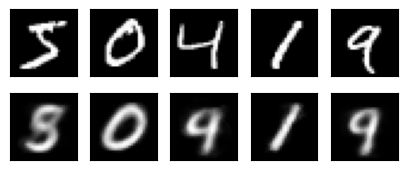

2회


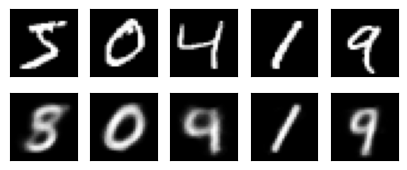

3회


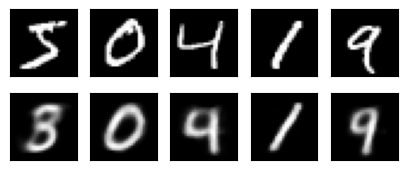

4회


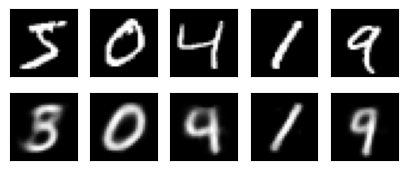

5회


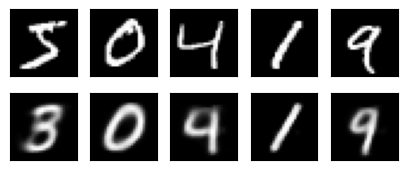

6회


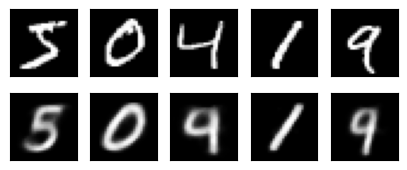

7회


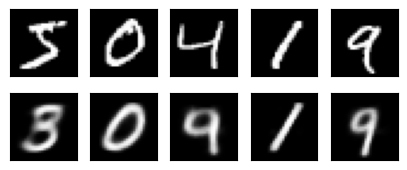

8회


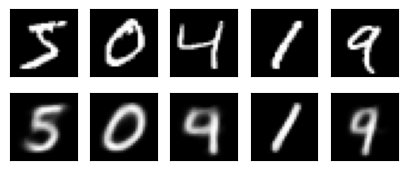

9회


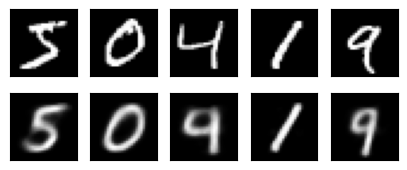

10회


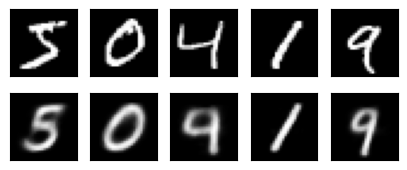

In [10]:
for epoch in range(1,EPOCHS+1):
    train(autoencoder,tr_ds_loader)

    tt_x=v_img.to(DEVICE)
    _,dc_data=autoencoder(tt_x)

    fig,a=plt.subplots(2,5,figsize=(5,2))
    print(f'{epoch}회')
    for i in range(5):
        img=v_img.data.numpy()[i].reshape(28,28)
        a[0][i].imshow(img,cmap='gray')
        a[0][i].set_xticks(())
        a[0][i].set_yticks(())
    for i in range(5):
        img=dc_data.to('cpu').data.numpy()[i].reshape(28,28)
        a[1][i].imshow(img,cmap='gray')
        a[1][i].set_xticks(())
        a[1][i].set_yticks(())
    plt.show()

# 패션 MNIST 데이터를 이용하여 오토인코더를 설계하고 학습하시오

1회


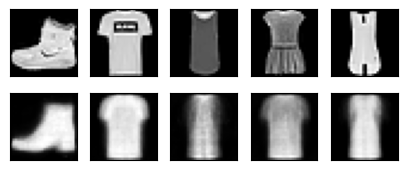

2회


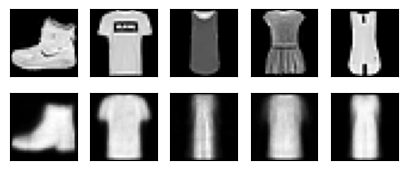

3회


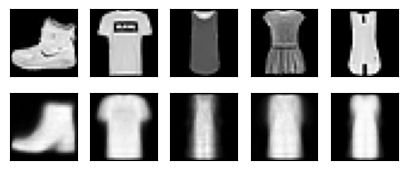

4회


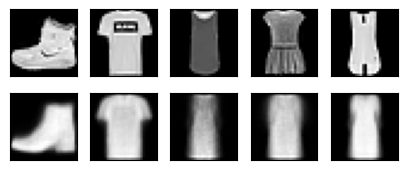

5회


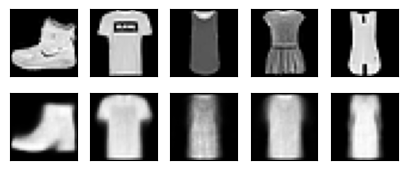

6회


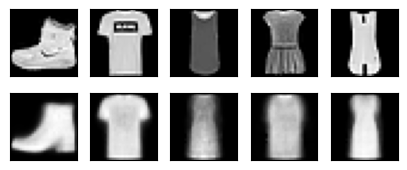

7회


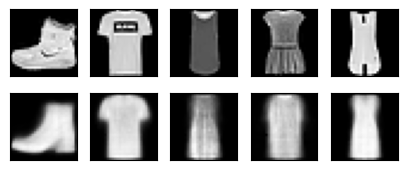

8회


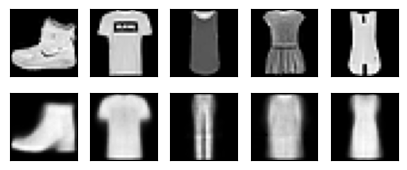

9회


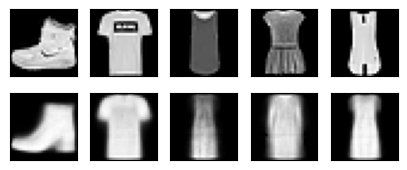

10회


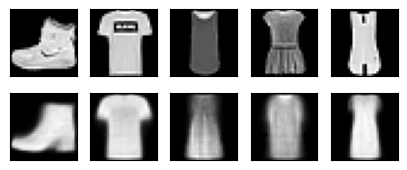

In [11]:
tr_ds = datasets.FashionMNIST(root='./data/',
                       train=True,
                       download=True,
                       transform=transforms.Compose([transforms.ToTensor()]))
BATCH_SIZE = 60000
tr_ds_loader = torch.utils.data.DataLoader(
    dataset=tr_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)
img, _ = next(iter(tr_ds_loader))
img.shape
img.mean(), img.std()
BATCH_SIZE = 64
EPOCHS = 10
# 데이터 수정 (노이즈 삽입)
# 1. 데이터 준비
transform = transforms.Compose([
    #transforms.RandomHorizontalFlip(),#데이터 증강(노이즈삽입)
    transforms.ToTensor(),  #입력 데이터 정리
    #transforms.Normalize((0.1307,),(0.3081,))
])  #데이터 사용 방식 내용 결정
tr_ds_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data/',
                   train=True,
                   download=False,
                   transform=transform
                   ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
tt_ds_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data/',
                   train=False,
                   transform=transform
                   ),
    batch_size=BATCH_SIZE,
    shuffle=True
)


class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded


autoencoder = Model().to(DEVICE)
opt = optim.Adam(autoencoder.parameters(), lr=0.005)
criterion = nn.MSELoss()
v_img = tr_ds.data[:5].view(-1, 28 * 28)
v_img = v_img.type(torch.FloatTensor) / 255.
v_img.shape


def train(m, tr_ds_loader):
    m.train()
    for i, (x, y) in enumerate(tr_ds_loader):
        data = x.view(-1, 28 * 28).to(DEVICE)
        target = x.view(-1, 28 * 28).to(DEVICE)
        label = y.to(DEVICE)

        encoded, decoded = m(data)

        loss = criterion(decoded, target)
        opt.zero_grad()
        loss.backward()
        opt.step()


for epoch in range(1, EPOCHS + 1):
    train(autoencoder, tr_ds_loader)

    tt_x = v_img.to(DEVICE)
    _, dc_data = autoencoder(tt_x)

    fig, a = plt.subplots(2, 5, figsize=(5, 2))
    print(f'{epoch}회')
    for i in range(5):
        img = v_img.data.numpy()[i].reshape(28, 28)
        a[0][i].imshow(img, cmap='gray')
        a[0][i].set_xticks(())
        a[0][i].set_yticks(())
    for i in range(5):
        img = dc_data.to('cpu').data.numpy()[i].reshape(28, 28)
        a[1][i].imshow(img, cmap='gray')
        a[1][i].set_xticks(())
        a[1][i].set_yticks(())
    plt.show()

# 오토인코더에 노이즈 추가 하여 복원

In [12]:
tr_ds = FashionMNIST('./data/', train=True,download=True,transform=transforms.Compose([transforms.ToTensor()]))
tr_ds_loader = torch.utils.data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

In [13]:
autoencoder=Model().to(DEVICE)
opt = optim.Adam(autoencoder.parameters(),lr=0.005)
criterion = nn.MSELoss()

In [14]:
def add_noise(img):
    noise = torch.randn(img.size())*0.2
    noise_img = img+noise
    return noise_img

In [15]:
def train(m,tr_ds_loader):
    m.train()
    avg_loss = 0
    for i,(x,y) in enumerate(tr_ds_loader):
        noise_img = add_noise(x)
        data=noise_img.view(-1,28*28).to(DEVICE)
        target=x.view(-1,28*28).to(DEVICE)
        label=y.to(DEVICE)

        encoded,decoded=m(data)

        loss=criterion(decoded,target)
        opt.zero_grad()
        loss.backward()
        opt.step()

        avg_loss += loss.item()
    return avg_loss/len(tr_ds_loader)

In [16]:
for epoch in range(1, EPOCHS + 1):
    loss = train(autoencoder, tr_ds_loader)
    print(f'{epoch}회, loss:{loss}')

1회, loss:0.03461584705374897
2회, loss:0.02590677503949162
3회, loss:0.02472059549227643
4회, loss:0.024050699449630817
5회, loss:0.02371498155814689
6회, loss:0.02339504287639724
7회, loss:0.023160805536517455
8회, loss:0.02306223617616429
9회, loss:0.022902088758073
10회, loss:0.022837130195979497


In [17]:
tt_ds = FashionMNIST('./data/', train=False,download=False,transform=transforms.Compose([transforms.ToTensor()]))
tt_ds_loader = torch.utils.data.DataLoader(tt_ds, batch_size=BATCH_SIZE, shuffle=True)
sample_data = tt_ds.data[0].view(-1, 28*28)
sample_data = sample_data.type(torch.FloatTensor) / 255.
oj_data = sample_data[0]
noise_data = add_noise(oj_data).to(DEVICE)
_,output = autoencoder(noise_data)

In [18]:
output.size(), oj_data.size(), noise_data.size()

(torch.Size([784]), torch.Size([784]), torch.Size([784]))

(28, 28) (28, 28) (28, 28)


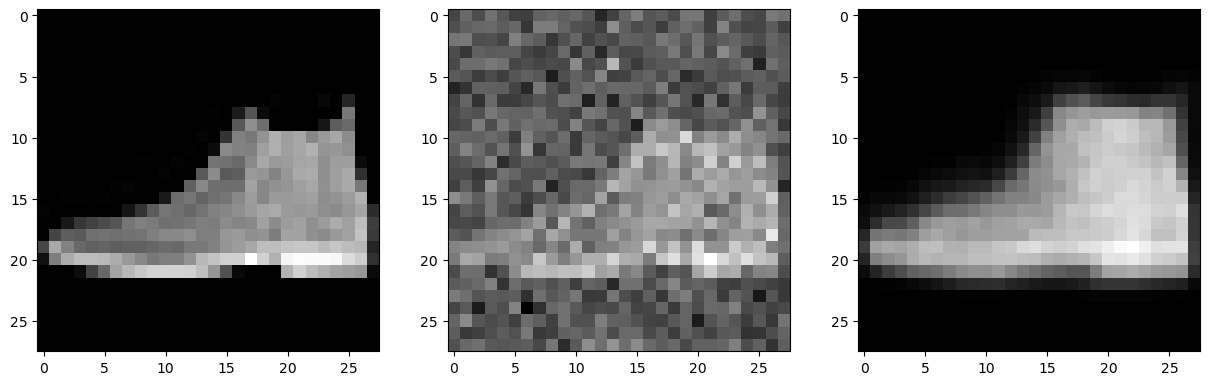

In [19]:
fig, a = plt.subplots(1,3,figsize=(15,15))
oj_img = oj_data.to('cpu').data.numpy().reshape(28, 28)
noisy_img = noise_data.to('cpu').data.numpy().reshape(28, 28)
out_img = output.to('cpu').data.numpy().reshape(28, 28)

print(oj_img.shape, noisy_img.shape, out_img.shape)

a[0].imshow(oj_img, cmap='gray')
a[1].imshow(noisy_img, cmap='gray')
a[2].imshow(out_img, cmap='gray')

# GAN 모델 생성

In [20]:
# 생성자
G = nn.Sequential(
    nn.Linear(64, 256),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Linear(256, 784),
    nn.Tanh()
)

In [21]:
# 판별자
D = nn.Sequential(
    nn.Linear(784, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 256),
    nn.LeakyReLU(),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

In [22]:
G = G.to(DEVICE)
D = D.to(DEVICE)

In [23]:
criterion = nn.BCELoss()
D_opt = optim.Adam(D.parameters(), lr=0.0002)
G_opt = optim.Adam(G.parameters(), lr=0.0002)

In [ ]:
EPOCHS = 300
for epoch in range(EPOCHS):
    for i, (x, y) in enumerate(tr_ds_loader):
        # data = x.reshape(-1, 784).to(DEVICE)
        data = x.reshape(BATCH_SIZE, -1).to(DEVICE)
        if data.shape[-1] != 784:
            continue
        r_label = torch.ones(BATCH_SIZE, 1).to(DEVICE)
        f_label = torch.zeros(BATCH_SIZE, 1).to(DEVICE)
        # 1. 진짜 데이터 판별
        output = D(data)
        D_loss_real = criterion(output, r_label)
        real_sc = output

        # 가짜 데이터 생성
        z = torch.randn(BATCH_SIZE, 64).to(DEVICE)
        f_data = G(z)

        # 2. 가짜 데이터 판별
        output = D(f_data)
        D_loss_fake = criterion(output, f_label)
        fake_sc = output

        # 판별오차 도출
        D_loss = D_loss_real + D_loss_fake

        # 초기화
        G_opt.zero_grad()
        D_opt.zero_grad()

        # 판별자 학습
        D_loss.backward()
        D_opt.step()

        # 생성오차 도출
        f_data = G(z)
        output = D(f_data)
        G_loss = criterion(output, r_label)

        # 생성자 학습
        G_opt.zero_grad()
        D_opt.zero_grad()

        G_loss.backward()
        G_opt.step()
    print(f'{epoch} 회, D_loss:{D_loss.item()}, G_loss:{G_loss.item()}, D(G(z)):{fake_sc}, D(x):{real_sc.mean()}')

In [35]:
z = torch.randn(BATCH_SIZE, 64).to(DEVICE)
ck_img1 = (G(z))

In [36]:
ck_img1.shape

torch.Size([64, 784])

In [37]:
# 생성자
G1 = nn.Sequential(
    nn.Linear(64, 256),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Linear(256, 784),
    nn.Tanh()
)

G1 = G1.to(DEVICE)

G1_opt = optim.Adam(G1.parameters(), lr=0.0002)

In [38]:
ck_img2 = G1(z)
ck_img2.shape

torch.Size([64, 784])

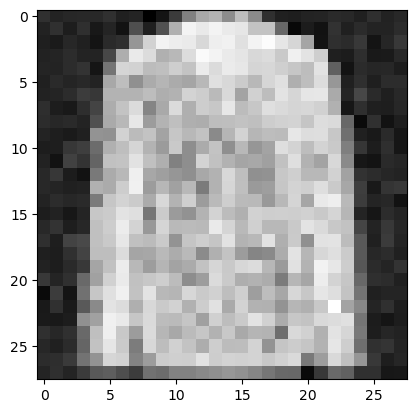

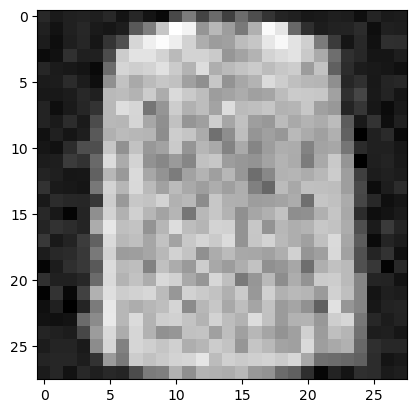

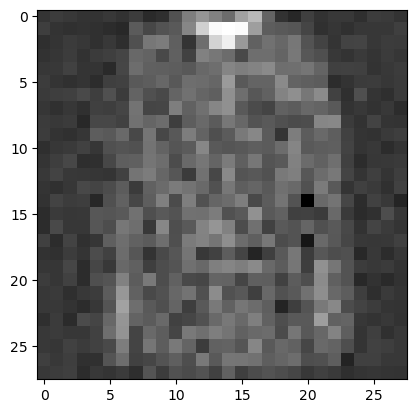

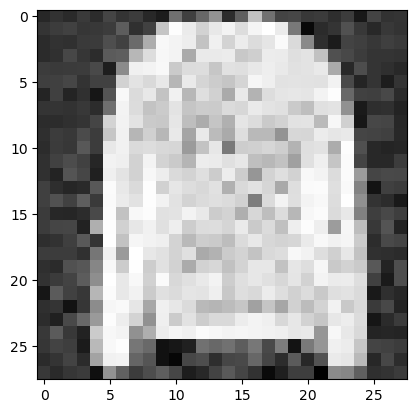

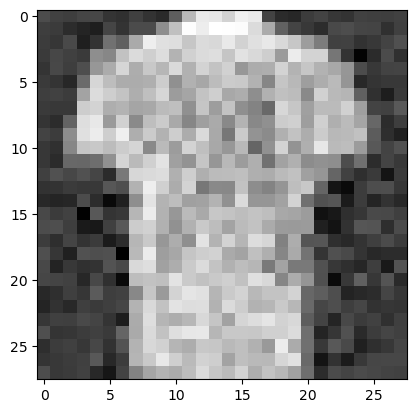

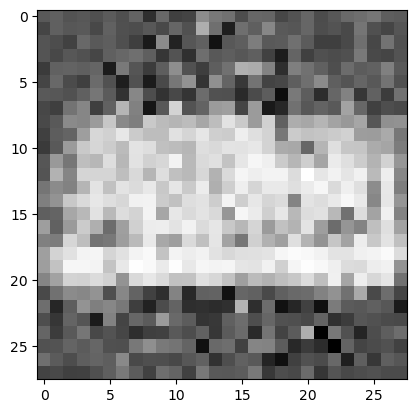

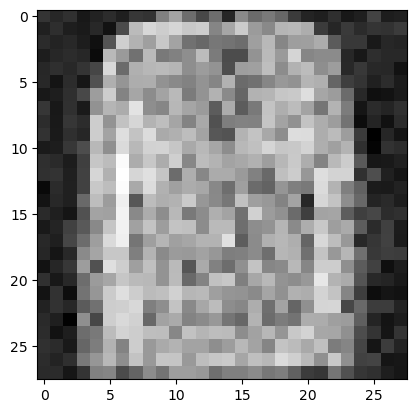

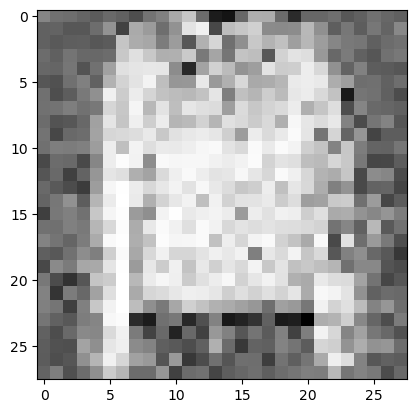

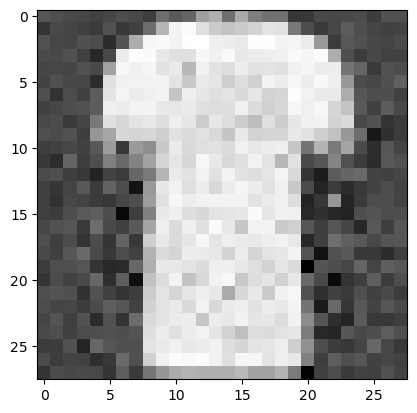

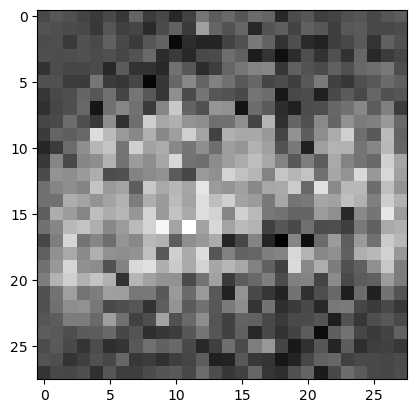

In [39]:
for i in range(10):
    plt.imshow(ck_img1.data.cpu().numpy()[i].reshape(28, 28), cmap='gray')
    plt.show()

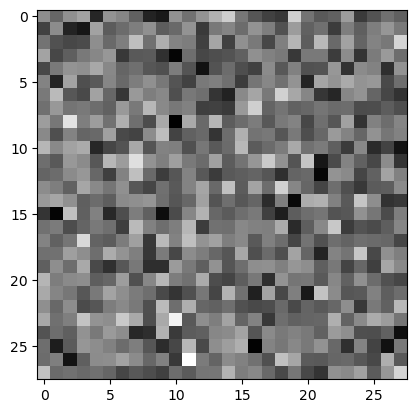

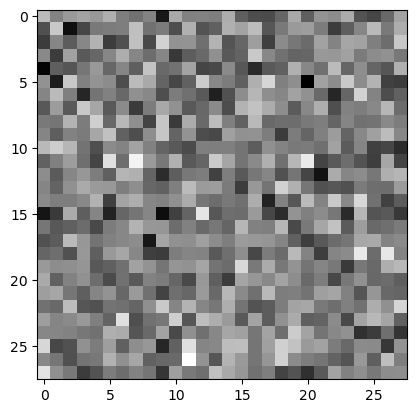

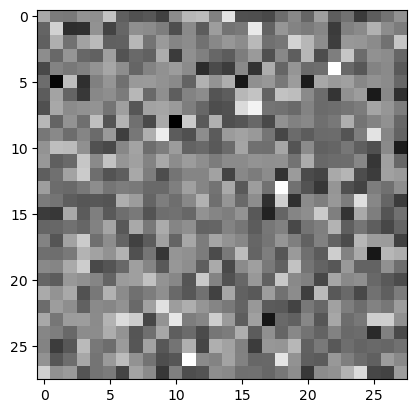

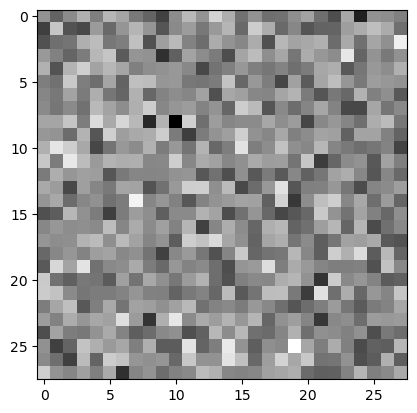

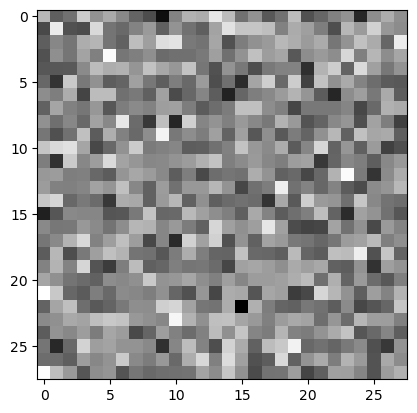

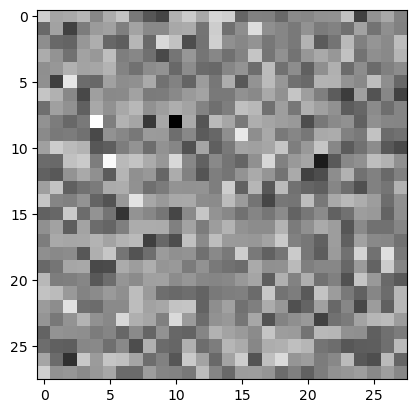

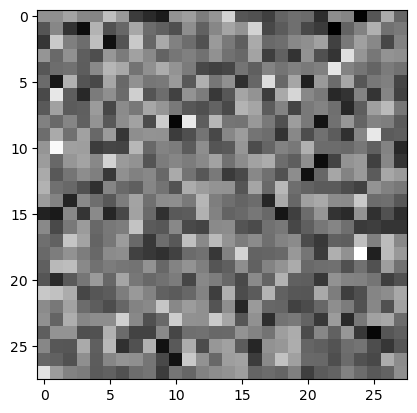

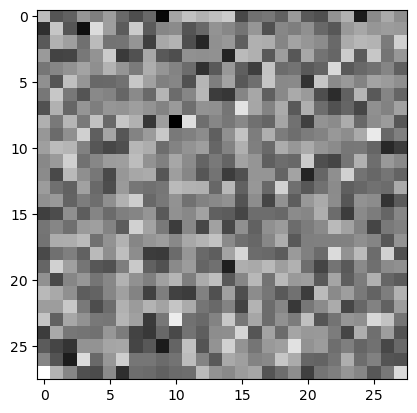

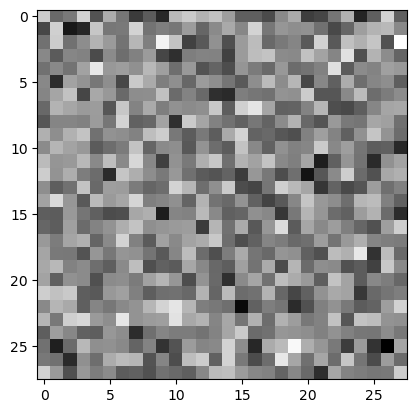

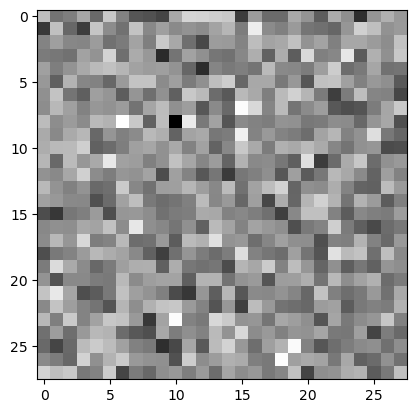

In [40]:
for i in range(10):
    plt.imshow(ck_img2.data.cpu().numpy()[i].reshape(28, 28), cmap='gray')
    plt.show()

# MNIST 데이터를 이용하여 GAN 모델을 만들어보자

In [41]:
# 1. 데이터 로드(데이터 분할 시, 남는 갯수 없이 만들기<배치 크기 선정>)
# 2. 판별자, 생성자의 모형은 자유롭게 단, 너무 깊게는 권장하지 않는다
# 3. 학습의 EPOCH는 50으로 한정

In [44]:
BATCH_SIZE = 128
tr_ds = datasets.MNIST(root='./data/',
                       train=True,
                       download=True,
                       transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]),)

tr_ds_loader = torch.utils.data.DataLoader(
    dataset=tr_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [12]:
# 생성자
G = nn.Sequential(
    nn.Linear(64, 256),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Linear(256, 784),
    nn.Tanh()
)

In [13]:
# 판별자
D = nn.Sequential(
    nn.Linear(784, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 256),
    nn.LeakyReLU(),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

In [14]:
G = G.to(DEVICE)
D = D.to(DEVICE)

In [15]:
criterion = nn.BCELoss()
D_opt = optim.Adam(D.parameters(), lr=0.0002)
G_opt = optim.Adam(G.parameters(), lr=0.0002)

In [31]:
EPOCHS = 200
for epoch in range(1, EPOCHS+1):
    for i, (x, y) in enumerate(tr_ds_loader):
        # data = x.reshape(-1, 784).to(DEVICE)
        data = x.reshape(BATCH_SIZE, -1).to(DEVICE)
        if data.shape[-1] != 784:
            continue
        r_label = torch.ones(BATCH_SIZE, 1).to(DEVICE)
        f_label = torch.zeros(BATCH_SIZE, 1).to(DEVICE)
        # 1. 진짜 데이터 판별
        output = D(data)
        D_loss_real = criterion(output, r_label)
        real_sc = output

        # 가짜 데이터 생성
        z = torch.randn(BATCH_SIZE, 64).to(DEVICE)
        f_data = G(z)

        # 2. 가짜 데이터 판별
        output = D(f_data)
        D_loss_fake = criterion(output, f_label)
        fake_sc = output

        # 판별오차 도출
        D_loss = D_loss_real + D_loss_fake

        # 초기화
        G_opt.zero_grad()
        D_opt.zero_grad()

        # 판별자 학습
        D_loss.backward()
        D_opt.step()

        # 생성오차 도출
        f_data = G(z)
        output = D(f_data)
        G_loss = criterion(output, r_label)

        # 생성자 학습
        G_opt.zero_grad()
        D_opt.zero_grad()

        G_loss.backward()
        G_opt.step()
    print(f'{epoch} 회, D_loss:{D_loss.item()}, G_loss:{G_loss.item()}, D(G(z)):{fake_sc.mean()}, D(x):{real_sc.mean()}')

1 회, D_loss:0.32960838079452515, G_loss:4.978873252868652, D(G(z)):0.055027417838573456, D(x):0.8597167730331421
2 회, D_loss:0.21015986800193787, G_loss:4.296684741973877, D(G(z)):0.09247112274169922, D(x):0.9483548998832703
3 회, D_loss:0.2881444990634918, G_loss:4.79160737991333, D(G(z)):0.07501459121704102, D(x):0.9186466932296753
4 회, D_loss:0.3538239598274231, G_loss:3.6511173248291016, D(G(z)):0.13952939212322235, D(x):0.9131256341934204
5 회, D_loss:0.30174165964126587, G_loss:3.6989803314208984, D(G(z)):0.1260715126991272, D(x):0.923303484916687
6 회, D_loss:0.23780637979507446, G_loss:3.9233601093292236, D(G(z)):0.08887434005737305, D(x):0.9214950799942017
7 회, D_loss:0.32975298166275024, G_loss:4.342059135437012, D(G(z)):0.08500756323337555, D(x):0.8932763338088989
8 회, D_loss:0.38702070713043213, G_loss:3.329887866973877, D(G(z)):0.13560061156749725, D(x):0.8863528966903687
9 회, D_loss:0.23874595761299133, G_loss:4.676138877868652, D(G(z)):0.08132976293563843, D(x):0.9229303598

In [32]:
z = torch.randn(BATCH_SIZE, 64).to(DEVICE)
ck_img1 = (G(z))

In [33]:
# 생성자
G1 = nn.Sequential(
    nn.Linear(64, 256),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Linear(256, 784),
    nn.Tanh()
)

In [34]:
G1 = G1.to(DEVICE)

In [48]:
G1_opt = optim.Adam(G1.parameters(), lr=0.0002)
ck_img2 = G1(z)

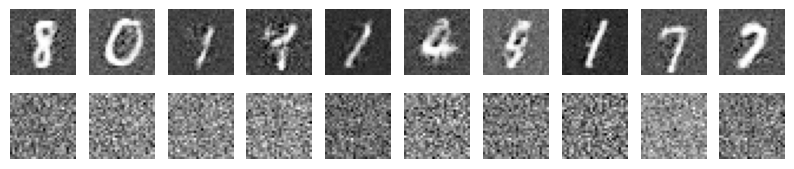

In [49]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(ck_img1.data.cpu().numpy()[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.subplot(2, 10, i + 10 + 1)
    plt.imshow(ck_img2.data.cpu().numpy()[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

# DCGAN 모델 생성

In [68]:
D = nn.Sequential(
    nn.Conv2d(1,12,kernel_size=3,padding='same'),#[1,28,28]이미지 입력
    nn.MaxPool2d(2),#[12,28,28]
    nn.Conv2d(12,24,kernel_size=3,padding='same'),#[12,14,14]
    nn.MaxPool2d(2),#[24,7,7]
    nn.Flatten(),#[1176]
    nn.Linear(1176,1),#정답도출
    nn.Sigmoid()#판별 활성화
)
for i in tr_ds_loader:
    print(D(i[0]).shape)
    break

In [ ]:
G = nn.Sequential(
    nn.Linear(100, 24*7*7),#z 이미지 입력을 위한 크기 조정
    nn.Unflatten(1, (24, 7, 7)),#백터 이미지 차원구조화[24,7,7]
    nn.ConvTranspose2d(24,12,4,2,1),#[12,14,14]
    nn.ConvTranspose2d(12,1,4,2,1),#[1,28,28]
)
z = torch.randn(1,100)
print(G(z).shape)